In [1]:
# --- Core Python ---
import os
import sys
from pathlib import Path
import h5py
import re

# Ensure notebook-local helper modules are importable
_NB_DIR = Path.cwd()
print(f"currently in {_NB_DIR}")
if (_NB_DIR / "resp_helper_functions.py").exists():
    print("helper functions exists in working directory, adding to sys.path")
    sys.path.insert(0, str(_NB_DIR))
else:
    # Fallback when notebook is launched from workspace root
    _NB_DIR = Path("notebooks/thomas_notebooks/resp_classification").resolve()
    if (_NB_DIR / "resp_helper_functions.py").exists():
        sys.path.insert(0, str(_NB_DIR))
    print("Helper functions didn't exist in working directory, resolving and adding to sys.path")

# --- Numerical & data analysis ---
import numpy as np
import pandas as pd

# --- Plotting ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Signal processing ---
from scipy.signal import butter, filtfilt, resample_poly, find_peaks

# --- Statistics ---
from scipy.stats import wilcoxon

# --- Machine learning & metrics ---
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# --- Specialized neurophysiology tools ---
import neurokit2 as nk

# All the functions used to load, clean, and verify respiration and BORIS data
from resp_helper_functions import *

# --- Pandas display settings ---
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 1000)


currently in c:\Users\thoma\Code\ResearchCode\respiratory_pilot
Helper functions didn't exist in working directory, resolving and adding to sys.path
Libraries loaded successfully


In [2]:
feature_matrix = pd.read_pickle(r"C:\Users\thoma\Code\ResearchCode\respiratory_pilot\notebooks\thomas_notebooks\resp_classification\data\raw-breathmetrics-features-session-3sec-rank")
feature_matrix.columns

Index(['WindowID', 'Start', 'Stop', 'Duration', 'n_breaths', 'breathing_rate_hz', 'mean_ibi_sec', 'cv_ibi', 'mean_inhale_dur_sec', 'cv_inhale_dur', 'mean_exhale_dur_sec', 'cv_exhale_dur', 'ie_ratio', 'mean_peak_insp_flow', 'mean_peak_exp_flow', 'cv_peak_insp_flow', 'mean_inhale_vol', 'mean_exhale_vol', 'mean_tidal_vol_proxy', 'cv_inhale_vol', 'ventilation_proxy', 'pct_breaths_with_inhale_pause', 'mean_inhale_pause_dur_sec', 'cv_inhale_pause_dur', 'inhale_pause_duty_cycle', 'pct_breaths_with_exhale_pause', 'mean_exhale_pause_dur_sec', 'cv_exhale_pause_dur', 'exhale_pause_duty_cycle', 'inhale_duty_cycle', 'exhale_duty_cycle', 'Trial', 'Recording', 'StandardizedRecording', 'Subject', 'Cagemate', 'PairID', 'SubjectRankCode', 'CagemateRankCode', 'SubjectRankName', 'CagemateRankName', 'Condition', 'RankLabel', 'Type', 'session_duration_sec', 'n_breaths_total', 'WindowSec', 'TargetSRate', 'MinBreathsPerWindow'], dtype='object')

In [3]:
# Classification target is RankLabel; Condition is a related covariate (often aligned).
print("RankLabel (actual prediction target):")
print(feature_matrix["RankLabel"].value_counts(dropna=False))
if "Condition" in feature_matrix.columns:
    print("\nRankLabel × Condition:")
    print(pd.crosstab(feature_matrix["RankLabel"], feature_matrix["Condition"], margins=True))

RankLabel (actual prediction target):
RankLabel
DOM    1257
SUB     971
NaN     100
Name: count, dtype: int64

RankLabel × Condition:
Condition   DOM  SUB   All
RankLabel                 
DOM        1257    0  1257
SUB           0  971   971
All        1257  971  2228


In [4]:
# --- Target & features ---
# Framing: in triads, RankLabel is pair-dependent — the same Subject can be DOM vs one
# Cagemate and SUB vs another. It is not a stable mouse-intrinsic label. Focal respiration
# alone (no partner context) is therefore underdetermined; strict LOSO + resp-only often ~chance.
# Set INCLUDE_PARTNER_CONTEXT=True for a quick diagnostic (one-hot Cagemate + PairID).
INCLUDE_PARTNER_CONTEXT = False

TARGET_COL = "RankLabel"

df = feature_matrix.copy()

# Window metadata, IDs, rank/covariate labels, and extraction settings — not breathmetrics
EXCLUDE_FROM_FEATURES = {
    TARGET_COL,
    "WindowID",
    "Start",
    "Stop",
    "Duration",
    "Trial",
    "Recording",
    "StandardizedRecording",
    "Subject",
    "Cagemate",
    "PairID",
    "SubjectRankCode",
    "CagemateRankCode",
    "SubjectRankName",
    "CagemateRankName",
    "Condition",
    "Type",
    "session_duration_sec",
    "n_breaths_total",
    "WindowSec",
    "TargetSRate",
    "MinBreathsPerWindow",
}

if "METADATA_COLS" in globals() and isinstance(METADATA_COLS, (list, tuple, set)):
    EXCLUDE_FROM_FEATURES.update(METADATA_COLS)

# Drop rows with no label
df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

candidate_feature_cols = [
    c for c in df.columns
    if c not in EXCLUDE_FROM_FEATURES and pd.api.types.is_numeric_dtype(df[c])
]

X_all = df[candidate_feature_cols].copy()

if INCLUDE_PARTNER_CONTEXT:
    _partner_cols = [c for c in ("Cagemate", "PairID") if c in df.columns]
    if not _partner_cols:
        raise ValueError("INCLUDE_PARTNER_CONTEXT requires Cagemate and/or PairID on df")
    _pfx = {"Cagemate": "cm", "PairID": "pair"}
    _part = df[_partner_cols].astype(str).fillna("NA")
    _dum = pd.get_dummies(
        _part,
        columns=_partner_cols,
        prefix=[_pfx[c] for c in _partner_cols],
        drop_first=False,
    )
    X_all = pd.concat([X_all.reset_index(drop=True), _dum.reset_index(drop=True)], axis=1)
    candidate_feature_cols = list(X_all.columns)
    print(
        f"INCLUDE_PARTNER_CONTEXT=True: added {_dum.shape[1]} partner dummy columns -> X_all {X_all.shape}"
    )

y = df[TARGET_COL].copy()

# For inner model-selection CV: group by focal subject so the same mouse is not in both train and val.
GROUP_KEY_FOR_CV = "Subject"
groups = df[GROUP_KEY_FOR_CV].copy() if GROUP_KEY_FOR_CV in df.columns else None

print(f"Rows after dropping missing {TARGET_COL}: {len(df)}")
print(f"Candidate numeric resp features ({len(candidate_feature_cols)}):")
print(candidate_feature_cols)
print(f"\nTarget ({TARGET_COL}) distribution:\n{y.value_counts(dropna=False)}")

# --- Cohort structure (label balance, subjects, pairs) ---
print("\n" + "=" * 60)
print("Cohort structure")
print("=" * 60)
_label_summary = pd.DataFrame({"n_windows": df.groupby(TARGET_COL, observed=True).size()})
_label_summary["n_subjects"] = df.groupby(TARGET_COL, observed=True)["Subject"].nunique()
if "Recording" in df.columns:
    _label_summary["n_recordings"] = df.groupby(TARGET_COL, observed=True)["Recording"].nunique()
print("\nPer RankLabel:")
display(_label_summary)

def _dominant_rank(s):
    return s.value_counts().index[0] if len(s) else np.nan


def _label_purity(s):
    if len(s) == 0:
        return np.nan
    return s.value_counts().iloc[0] / len(s)


_per_subj = df.groupby("Subject", observed=True).agg(
    n_windows=("Subject", "size"),
    dominant_rank=(TARGET_COL, _dominant_rank),
    label_purity=(TARGET_COL, _label_purity),
)
if "Recording" in df.columns:
    _per_subj["n_recordings"] = df.groupby("Subject", observed=True)["Recording"].nunique()
print("\nPer Subject (purity = fraction of windows with majority RankLabel):")
display(_per_subj.sort_index())

_n_ranks = df.groupby("Subject", observed=True)[TARGET_COL].nunique()
print(
    f"\nSubjects with >1 distinct {TARGET_COL} (pair-dependent ranks): "
    f"{(_n_ranks > 1).sum()} / {len(_n_ranks)}"
)
print("Distinct-rank counts per subject:")
display(_n_ranks.value_counts().sort_index())

if "PairID" in df.columns:
    _pair = (
        df.groupby(["PairID", TARGET_COL], observed=True)
        .size()
        .unstack(fill_value=0)
    )
    print("\nWindows per PairID × RankLabel:")
    display(_pair.sort_index())
else:
    print("\nNo PairID column — skipped pair-level table")


Rows after dropping missing RankLabel: 2228
Candidate numeric resp features (27):
['n_breaths', 'breathing_rate_hz', 'mean_ibi_sec', 'cv_ibi', 'mean_inhale_dur_sec', 'cv_inhale_dur', 'mean_exhale_dur_sec', 'cv_exhale_dur', 'ie_ratio', 'mean_peak_insp_flow', 'mean_peak_exp_flow', 'cv_peak_insp_flow', 'mean_inhale_vol', 'mean_exhale_vol', 'mean_tidal_vol_proxy', 'cv_inhale_vol', 'ventilation_proxy', 'pct_breaths_with_inhale_pause', 'mean_inhale_pause_dur_sec', 'cv_inhale_pause_dur', 'inhale_pause_duty_cycle', 'pct_breaths_with_exhale_pause', 'mean_exhale_pause_dur_sec', 'cv_exhale_pause_dur', 'exhale_pause_duty_cycle', 'inhale_duty_cycle', 'exhale_duty_cycle']

Target (RankLabel) distribution:
RankLabel
DOM    1257
SUB     971
Name: count, dtype: int64

Cohort structure

Per RankLabel:


,n_windows,n_subjects,n_recordings
RankLabel,,,
DOM,1257,13,13
SUB,971,10,10



Per Subject (purity = fraction of windows with majority RankLabel):


,n_windows,dominant_rank,label_purity,n_recordings
Subject,,,,
1_1,198,DOM,0.505051,2
1_2,99,DOM,1.000000,1
1_3,195,DOM,0.512821,2
2_1,100,DOM,1.000000,1
2_2,200,SUB,0.500000,2
3_1,191,SUB,0.513089,2
3_2,100,DOM,1.000000,1
3_3,197,SUB,0.507614,2
4_1,98,SUB,1.000000,1



Subjects with >1 distinct RankLabel (pair-dependent ranks): 6 / 17
Distinct-rank counts per subject:


RankLabel
1    11
2     6
Name: count, dtype: int64


Windows per PairID × RankLabel:


RankLabel,DOM,SUB
PairID,,
1,299,193
2,200,100
3,290,198
4,199,98
5,92,97
6,79,0
7,98,97
8,0,188


In [5]:
def iter_loso_subject_strict(df, subject_col="Subject", cagemate_col="Cagemate"):
    """Leave-one-subject-out with no leakage from the held-out mouse.

    Test: rows where `subject_col` is the held-out subject (all their focal recordings).
    Train: rows where that mouse appears neither as subject nor as cagemate, so its
    breathing is not in the training set in any role.
    """
    subjects = pd.unique(df[subject_col].dropna())
    sub = df[subject_col]
    cm = df[cagemate_col]
    for s in subjects:
        test_mask = sub == s
        train_mask = (sub != s) & (cm.isna() | (cm != s))
        train_idx = np.flatnonzero(train_mask.to_numpy())
        test_idx = np.flatnonzero(test_mask.to_numpy())
        if len(test_idx) == 0 or len(train_idx) == 0:
            continue
        yield s, train_idx, test_idx


def iter_loso_subject_relaxed(df, subject_col="Subject"):
    """LOSO: test on focal subject s; train where Subject != s.
    Held-out mouse may still appear as Cagemate in training (looser than strict)."""
    subjects = pd.unique(df[subject_col].dropna())
    sub = df[subject_col]
    for s in subjects:
        test_mask = sub == s
        train_mask = sub != s
        train_idx = np.flatnonzero(train_mask.to_numpy())
        test_idx = np.flatnonzero(test_mask.to_numpy())
        if len(test_idx) == 0 or len(train_idx) == 0:
            continue
        yield s, train_idx, test_idx


def iter_lopo_pair(df, pair_col="PairID"):
    """Leave-one-pair-out: test all windows from one pair; train on remaining pairs."""
    if pair_col not in df.columns:
        return
    pairs = pd.unique(df[pair_col].dropna())
    pcol = df[pair_col]
    for p in pairs:
        test_mask = pcol == p
        train_mask = pcol != p
        train_idx = np.flatnonzero(train_mask.to_numpy())
        test_idx = np.flatnonzero(test_mask.to_numpy())
        if len(test_idx) == 0 or len(train_idx) == 0:
            continue
        yield p, train_idx, test_idx


# --- Inner model-selection CV (stratified + grouped by focal Subject) ---
if groups is not None and groups.nunique() >= 3:
    n_splits = min(5, groups.nunique())
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    gname = GROUP_KEY_FOR_CV or "group"
    cv_mode = (
        f"StratifiedGroupKFold(n_splits={n_splits}, shuffle=True, random_state=42) "
        f"[group={gname}]"
    )
else:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_mode = "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"

# Drop feature columns with too many missing values
MAX_MISSING_FRAC = 0.40
missing_frac = X_all.isna().mean(axis=0)
kept_feature_cols = missing_frac[missing_frac <= MAX_MISSING_FRAC].index.tolist()
dropped_feature_cols = missing_frac[missing_frac > MAX_MISSING_FRAC].sort_values(ascending=False)

X = X_all[kept_feature_cols].copy()

preprocess_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess_impute_only = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

logreg_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(max_iter=5000, class_weight="balanced")),
])

svm_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=42)),
])

rf_clf = Pipeline([
    ("preprocess", preprocess_impute_only),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        max_depth=None,
        random_state=42,
        n_jobs=-1,
    )),
])

print(f"Rows: {len(df)}")
print(f"Target class counts:\n{y.value_counts(dropna=False)}\n")
print(f"Candidate numeric resp features: {len(candidate_feature_cols)}")
print(f"Features kept (<= {MAX_MISSING_FRAC:.0%} missing): {X.shape[1]}")
print(f"Features dropped (> {MAX_MISSING_FRAC:.0%} missing): {len(dropped_feature_cols)}")
if len(dropped_feature_cols):
    print("Dropped columns and missing fraction:")
    display(dropped_feature_cols.to_frame(name="missing_fraction"))

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"groups available: {groups is not None}")
print(f"CV strategy (GridSearch / learning curves): {cv_mode}")

fold_rows = []
for s, tr, te in iter_loso_subject_strict(df):
    fold_rows.append({"held_out_subject": s, "n_train": len(tr), "n_test": len(te)})
loso_summary = pd.DataFrame(fold_rows)
print(f"\nStrict LOSO folds (no train rows where held-out mouse is Subject or Cagemate): {len(loso_summary)}")
display(loso_summary)

fold_rows_relaxed = [
    {"held_out_subject": s, "n_train": len(tr), "n_test": len(te)}
    for s, tr, te in iter_loso_subject_relaxed(df)
]
loso_relaxed_summary = pd.DataFrame(fold_rows_relaxed)
print(f"\nRelaxed LOSO folds (train may include held-out as Cagemate): {len(loso_relaxed_summary)}")
display(loso_relaxed_summary)

if "PairID" in df.columns:
    fold_rows_lopo = [
        {"held_out_pair": p, "n_train": len(tr), "n_test": len(te)}
        for p, tr, te in iter_lopo_pair(df)
    ]
    lopo_summary = pd.DataFrame(fold_rows_lopo)
    print(f"\nLeave-one-pair-out folds: {len(lopo_summary)}")
    display(lopo_summary)
else:
    lopo_summary = pd.DataFrame()

classes = np.sort(pd.unique(y.dropna()))


def _recording_level_from_windows(y_true_arr, y_pred_arr, recordings, label_classes):
    """One label per recording via majority vote over its windows."""
    d = pd.DataFrame({"Recording": recordings, "y_true": y_true_arr, "y_pred": y_pred_arr})

    def _mode(s):
        m = s.mode()
        return m.iloc[0] if len(m) else np.nan

    yt = d.groupby("Recording", observed=True)["y_true"].agg(_mode)
    yp = d.groupby("Recording", observed=True)["y_pred"].agg(_mode)
    common = yt.index.intersection(yp.index)
    yt = yt.loc[common]
    yp = yp.loc[common]
    if len(common) == 0:
        return np.nan, np.nan
    ba = balanced_accuracy_score(yt, yp)
    f1 = f1_score(yt, yp, labels=label_classes, average="macro", zero_division=0)
    return ba, f1


def evaluate_rank_protocol(
    base_model,
    model_name,
    split_factory,
    protocol_title,
    shuffle_labels=False,
    verbose=True,
    print_pooled_report=True,
):
    """Run one CV protocol. Use class_weight on estimators only — do not stack sample_weight."""
    folds = list(split_factory())
    if len(folds) == 0:
        raise ValueError(f"No CV folds for protocol: {protocol_title}")

    y_eval = y.copy()
    if shuffle_labels:
        rng = np.random.RandomState(42)
        y_eval = pd.Series(rng.permutation(y_eval.values), index=y_eval.index)

    bal_w, f1_w = [], []
    bal_r, f1_r = [], []
    y_true_all, y_pred_all = [], []

    for fold_idx, (held_id, train_idx, test_idx) in enumerate(folds, start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_eval.iloc[train_idx], y_eval.iloc[test_idx]

        model = clone(base_model)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        ba = balanced_accuracy_score(y_test, y_pred)
        mf1 = f1_score(y_test, y_pred, labels=classes, average="macro", zero_division=0)

        bal_w.append(ba)
        f1_w.append(mf1)

        if "Recording" in df.columns:
            rec_col = df.iloc[test_idx]["Recording"].values
            bar, f1rec = _recording_level_from_windows(
                y_test.values, y_pred, rec_col, classes
            )
        else:
            bar, f1rec = np.nan, np.nan
        bal_r.append(bar)
        f1_r.append(f1rec)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        if verbose:
            print(
                f"[{model_name}] {protocol_title} | held_out={held_id} (fold {fold_idx}): "
                f"window bal_acc={ba:.3f}, macro_f1={mf1:.3f} | "
                f"recording bal_acc={bar:.3f}, macro_f1={f1rec:.3f}"
            )

    bal_w = np.asarray(bal_w, dtype=float)
    f1_w = np.asarray(f1_w, dtype=float)
    bal_r = np.asarray(bal_r, dtype=float)
    f1_r = np.asarray(f1_r, dtype=float)

    tag = "  [label shuffle]" if shuffle_labels else ""
    if verbose:
        print(f"\n[{model_name}] {protocol_title} — window-level mean ± std{tag}:")
        print(f"  balanced accuracy: {bal_w.mean():.3f} ± {bal_w.std():.3f}  (n={len(bal_w)} folds)")
        print(f"  macro F1:          {f1_w.mean():.3f} ± {f1_w.std():.3f}")
        print(f"\n[{model_name}] {protocol_title} — recording-level (vote){tag}:")
        print(f"  balanced accuracy: {np.nanmean(bal_r):.3f} ± {np.nanstd(bal_r):.3f}")
        print(f"  macro F1:          {np.nanmean(f1_r):.3f} ± {np.nanstd(f1_r):.3f}")

    if print_pooled_report and not shuffle_labels and verbose:
        print(f"\n[{model_name}] Pooled window-level OOF ({protocol_title}):")
        print(classification_report(y_true_all, y_pred_all, labels=classes, zero_division=0))
        cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
        cm_df = pd.DataFrame(
            cm,
            index=[f"true_{c}" for c in classes],
            columns=[f"pred_{c}" for c in classes],
        )
        display(cm_df)

    return {
        "protocol": protocol_title,
        "mean_bal_acc_w": float(bal_w.mean()),
        "std_bal_acc_w": float(bal_w.std()),
        "mean_macro_f1_w": float(f1_w.mean()),
        "std_macro_f1_w": float(f1_w.std()),
        "mean_bal_acc_rec": float(np.nanmean(bal_r)),
        "mean_macro_f1_rec": float(np.nanmean(f1_r)),
        "n_folds": int(len(bal_w)),
    }


def evaluate_subject_loso_strict(base_model, model_name, shuffle_labels=False, **kwargs):
    if len(loso_summary) == 0:
        raise ValueError("No strict LOSO folds; check Subject/Cagemate columns and data.")
    return evaluate_rank_protocol(
        base_model,
        model_name,
        lambda: iter_loso_subject_strict(df),
        "strict LOSO",
        shuffle_labels=shuffle_labels,
        **kwargs,
    )


def evaluate_subject_loso_relaxed(base_model, model_name, shuffle_labels=False, **kwargs):
    return evaluate_rank_protocol(
        base_model,
        model_name,
        lambda: iter_loso_subject_relaxed(df),
        "relaxed LOSO",
        shuffle_labels=shuffle_labels,
        **kwargs,
    )


def evaluate_lopo_pair_protocol(base_model, model_name, shuffle_labels=False, **kwargs):
    if "PairID" not in df.columns:
        raise ValueError("PairID missing; cannot run leave-one-pair-out.")
    return evaluate_rank_protocol(
        base_model,
        model_name,
        lambda: iter_lopo_pair(df),
        "leave-one-pair-out",
        shuffle_labels=shuffle_labels,
        **kwargs,
    )

Rows: 2228
Target class counts:
RankLabel
DOM    1257
SUB     971
Name: count, dtype: int64

Candidate numeric resp features: 27
Features kept (<= 40% missing): 25
Features dropped (> 40% missing): 2
Dropped columns and missing fraction:


,missing_fraction
cv_inhale_pause_dur,0.987882
cv_exhale_pause_dur,0.877020


X shape: (2228, 25)
y shape: (2228,)
groups available: True
CV strategy (GridSearch / learning curves): StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42) [group=Subject]

Strict LOSO folds (no train rows where held-out mouse is Subject or Cagemate): 17


,held_out_subject,n_train,n_test
0,1_1,1930,198
1,1_2,1936,99
2,1_3,1834,195
3,2_1,2028,100
4,2_2,1928,200
5,3_1,1940,191
6,3_2,1930,100
7,3_3,1838,197
8,4_1,1931,98
9,4_2,2031,99



Relaxed LOSO folds (train may include held-out as Cagemate): 17


,held_out_subject,n_train,n_test
0,1_1,2030,198
1,1_2,2129,99
2,1_3,2033,195
3,2_1,2128,100
4,2_2,2028,200
5,3_1,2037,191
6,3_2,2128,100
7,3_3,2031,197
8,4_1,2130,98
9,4_2,2129,99



Leave-one-pair-out folds: 8


,held_out_pair,n_train,n_test
0,1,1736,492
1,2,1928,300
2,3,1740,488
3,4,1931,297
4,5,2039,189
5,6,2149,79
6,7,2033,195
7,8,2040,188


In [6]:
if groups is None:
    raise ValueError(
        f"No grouping column for LOSO. Expected {GROUP_KEY_FOR_CV!r} on df (see target/features cell)."
    )

print("=" * 80)
print("Protocol comparison — LogisticRegression (quiet; see table)")
print("  strict LOSO: held-out mouse never in train as Subject or Cagemate")
print("  relaxed LOSO: held-out not focal Subject; may appear as Cagemate in train")
print("  leave-one-pair-out: hold out all windows from one PairID")
print(
    "  If rank is pair-dependent: expect strict ~chance, relaxed often higher, "
    "LOPO as the evaluation closest to 'new pair' generalization."
)
print("=" * 80 + "\n")

_cmp_rows = []
_cmp_rows.append(
    evaluate_rank_protocol(
        logreg_clf,
        "LogReg",
        lambda: iter_loso_subject_strict(df),
        "strict LOSO",
        verbose=False,
        print_pooled_report=False,
    )
)
_cmp_rows.append(
    evaluate_rank_protocol(
        logreg_clf,
        "LogReg",
        lambda: iter_loso_subject_relaxed(df),
        "relaxed LOSO",
        verbose=False,
        print_pooled_report=False,
    )
)
if "PairID" in df.columns and len(lopo_summary) > 0:
    _cmp_rows.append(
        evaluate_rank_protocol(
            logreg_clf,
            "LogReg",
            lambda: iter_lopo_pair(df),
            "leave-one-pair-out",
            verbose=False,
            print_pooled_report=False,
        )
    )
protocol_compare_df = pd.DataFrame(_cmp_rows)
display(protocol_compare_df)

print(
    "\nNext steps if rank signal is weak: longer windows (5–10 s), recording-level aggregation, "
    "or features that capture bout / interaction context — not changed in this notebook.\n"
)

print("=" * 80)
print(f"Per-{GROUP_KEY_FOR_CV} class balance (windows) — inspect before strict LOSO")
print("=" * 80)
_subject_bal = (
    df.assign(_subject_group=groups.values)
    .groupby("_subject_group", observed=True)[TARGET_COL]
    .value_counts()
    .unstack(fill_value=0)
)
display(_subject_bal.sort_index())
print(f"\nUnique {GROUP_KEY_FOR_CV} (grouping variable): {groups.nunique()}")

print("\n" + "=" * 80)
print("Primary evaluation: strict Leave-One-Subject-Out (train excludes held-out mouse as Subject or Cagemate)")
print("Question: Do respiration features generalize rank label to a new focal subject?")
print("=" * 80 + "\n")

_strict_loso_logreg = evaluate_subject_loso_strict(logreg_clf, "LogisticRegression", shuffle_labels=False)
print("\n" + "=" * 80 + "\n")
_strict_loso_svm = evaluate_subject_loso_strict(svm_clf, "SVM", shuffle_labels=False)
print("\n" + "=" * 80 + "\n")
_strict_loso_rf = evaluate_subject_loso_strict(rf_clf, "RandomForest", shuffle_labels=False)

print("\n" + "=" * 80)
print("Label-shuffle sanity check (LogisticRegression). High score => possible leakage or insufficient folds.")
print("=" * 80 + "\n")
evaluate_subject_loso_strict(logreg_clf, "LogisticRegression_shuffled_y", shuffle_labels=True)

Protocol comparison — LogisticRegression (quiet; see table)
  strict LOSO: held-out mouse never in train as Subject or Cagemate
  relaxed LOSO: held-out not focal Subject; may appear as Cagemate in train
  leave-one-pair-out: hold out all windows from one PairID
  If rank is pair-dependent: expect strict ~chance, relaxed often higher, LOPO as the evaluation closest to 'new pair' generalization.



c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sk

,protocol,mean_bal_acc_w,std_bal_acc_w,mean_macro_f1_w,std_macro_f1_w,mean_bal_acc_rec,mean_macro_f1_rec,n_folds
0,strict LOSO,0.414997,0.159284,0.335185,0.133834,0.411765,0.284314,17
1,relaxed LOSO,0.401459,0.129295,0.327713,0.119057,0.294118,0.196078,17
2,leave-one-pair-out,0.420892,0.106015,0.386219,0.114848,0.364583,0.355655,8



Next steps if rank signal is weak: longer windows (5–10 s), recording-level aggregation, or features that capture bout / interaction context — not changed in this notebook.

Per-Subject class balance (windows) — inspect before strict LOSO


RankLabel,DOM,SUB
_subject_group,,
1_1,100,98
1_2,99,0
1_3,100,95
2_1,100,0
2_2,100,100
3_1,93,98
3_2,100,0
3_3,97,100
4_1,0,98


...


[LogisticRegression_shuffled_y] strict LOSO | held_out=2_2 (fold 5): window bal_acc=0.482, macro_f1=0.481 | recording bal_acc=0.500, macro_f1=0.333
[LogisticRegression_shuffled_y] strict LOSO | held_out=3_1 (fold 6): window bal_acc=0.565, macro_f1=0.526 | recording bal_acc=0.000, macro_f1=0.000
[LogisticRegression_shuffled_y] strict LOSO | held_out=3_2 (fold 7): window bal_acc=0.463, macro_f1=0.463 | recording bal_acc=1.000, macro_f1=0.500
[LogisticRegression_shuffled_y] strict LOSO | held_out=3_3 (fold 8): window bal_acc=0.465, macro_f1=0.465 | recording bal_acc=0.500, macro_f1=0.333


c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes n

[LogisticRegression_shuffled_y] strict LOSO | held_out=4_1 (fold 9): window bal_acc=0.523, macro_f1=0.520 | recording bal_acc=0.000, macro_f1=0.000
[LogisticRegression_shuffled_y] strict LOSO | held_out=4_2 (fold 10): window bal_acc=0.480, macro_f1=0.475 | recording bal_acc=0.000, macro_f1=0.000
[LogisticRegression_shuffled_y] strict LOSO | held_out=4_3 (fold 11): window bal_acc=0.523, macro_f1=0.513 | recording bal_acc=0.000, macro_f1=0.000
[LogisticRegression_shuffled_y] strict LOSO | held_out=5_1 (fold 12): window bal_acc=0.494, macro_f1=0.493 | recording bal_acc=0.500, macro_f1=0.333
[LogisticRegression_shuffled_y] strict LOSO | held_out=6_2 (fold 13): window bal_acc=0.546, macro_f1=0.544 | recording bal_acc=0.000, macro_f1=0.000
[LogisticRegression_shuffled_y] strict LOSO | held_out=7_1 (fold 14): window bal_acc=0.439, macro_f1=0.406 | recording bal_acc=0.000, macro_f1=0.000
[LogisticRegression_shuffled_y] strict LOSO | held_out=7_2 (fold 15): window bal_acc=0.525, macro_f1=0.508 

c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


{'protocol': 'strict LOSO',
 'mean_bal_acc_w': 0.49302389161275095,
 'std_bal_acc_w': 0.03761223153250295,
 'mean_macro_f1_w': 0.47964189237801613,
 'std_macro_f1_w': 0.03996350423582305,
 'mean_bal_acc_rec': 0.29411764705882354,
 'mean_macro_f1_rec': 0.16666666666666666,
 'n_folds': 17}

Learning-curve CV: StratifiedGroupKFold(n_splits=5, shuffle=True) [subject-level groups]
Regularized models — LOSO evaluation below still uses **strict** LOSO (subject+cagemate exclusion).
Learning curves use StratifiedGroupKFold by Subject only: train/val splits may still contain the held-out mouse as Cagemate, so they answer a **looser** question than strict LOSO. Do not compare curve height directly to strict LOSO numbers.


  LogisticRegression_L2



c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sk

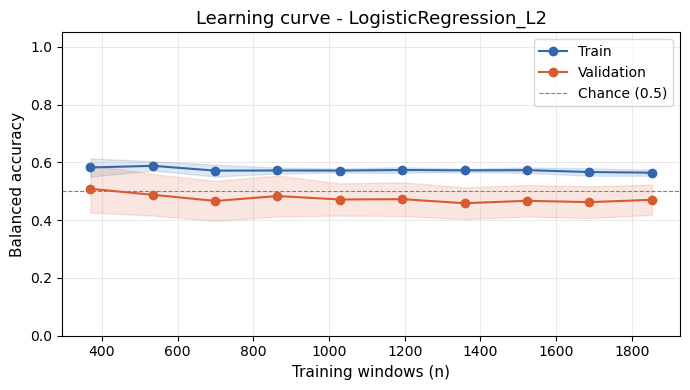

[LogisticRegression_L2] Validation curve verdict: flat but low - model may need different features, not more data


  SVM_regularized



c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sk

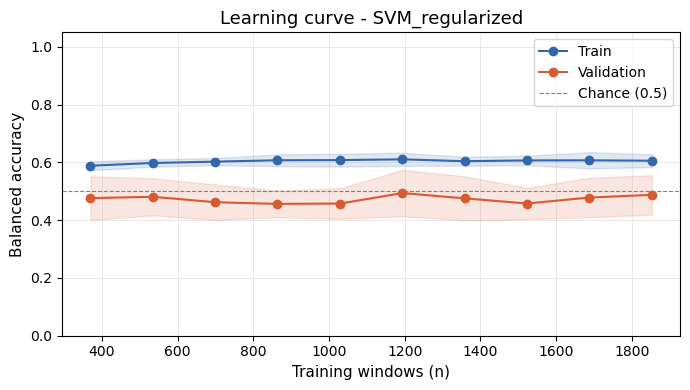

[SVM_regularized] Validation curve verdict: still rising - consider collecting more windows


  RandomForest_regularized



c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sk

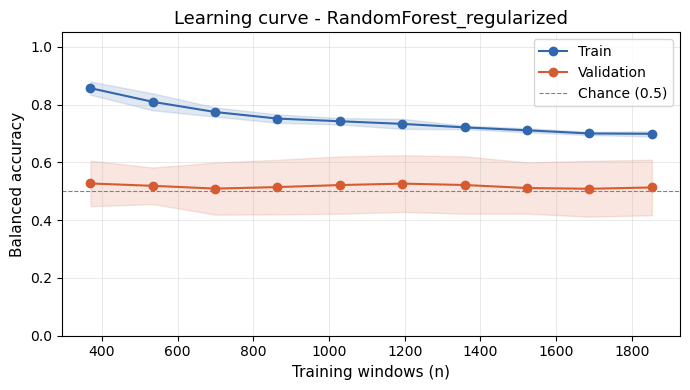

[RandomForest_regularized] Validation curve verdict: flat but low - model may need different features, not more data



,protocol,mean_bal_acc_w,std_bal_acc_w,mean_macro_f1_w,std_macro_f1_w,mean_bal_acc_rec,mean_macro_f1_rec,n_folds
0,strict LOSO,0.404979,0.157014,0.326476,0.129306,0.323529,0.205882,17
1,strict LOSO,0.424555,0.312780,0.291403,0.177577,0.441176,0.245098,17
2,strict LOSO,0.468066,0.196085,0.349865,0.125304,0.382353,0.215686,17


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, learning_curve

# Explicitly regularized models (separate pipelines from the default cell above)

preprocess_numeric = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preprocess_impute_only = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

logreg_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(
        penalty="l2",
        C=0.1,
        class_weight="balanced",
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])

svm_clf = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", SVC(
        kernel="rbf",
        C=0.1,
        gamma="scale",
        class_weight="balanced",
        random_state=42
    ))
])

rf_clf = Pipeline([
    ("preprocess", preprocess_impute_only),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        bootstrap=True,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Learning curves use grouped CV by focal subject (same idea as inner CV in valence notebook)
if groups is not None and pd.Series(groups).nunique() >= 3:
    n_splits_eval = min(5, pd.Series(groups).nunique())
    cv_lc = StratifiedGroupKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_lc_mode = f"StratifiedGroupKFold(n_splits={n_splits_eval}, shuffle=True) [subject-level groups]"
else:
    n_splits_eval = 5
    cv_lc = StratifiedKFold(n_splits=n_splits_eval, shuffle=True, random_state=42)
    cv_lc_mode = "StratifiedKFold(n_splits=5, shuffle=True, random_state=42)"

print(f"Learning-curve CV: {cv_lc_mode}")
print(
    "Regularized models — LOSO evaluation below still uses **strict** LOSO (subject+cagemate exclusion).\n"
    "Learning curves use StratifiedGroupKFold by Subject only: train/val splits may still contain the "
    "held-out mouse as Cagemate, so they answer a **looser** question than strict LOSO. "
    "Do not compare curve height directly to strict LOSO numbers.\n"
)


def plot_learning_curve(base_model, model_name, train_sizes=None):
    # Min fraction >0.1: tiny slices of ordered/grouped rows can be single-class and break liblinear.
    if train_sizes is None:
        train_sizes = np.linspace(0.2, 1.0, 10)
    lc_kwargs = dict(
        estimator=base_model,
        X=X,
        y=y,
        cv=cv_lc,
        scoring="balanced_accuracy",
        train_sizes=train_sizes,
        shuffle=True,
        random_state=42,
        n_jobs=-1,
        return_times=False,
    )
    if groups is not None and pd.Series(groups).nunique() >= 3:
        lc_kwargs["groups"] = groups

    train_sizes_abs, train_scores, val_scores = learning_curve(**lc_kwargs)

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(train_sizes_abs, train_mean, "o-", color="#3266ad", label="Train")
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color="#3266ad")
    ax.plot(train_sizes_abs, val_mean, "o-", color="#d85a30", label="Validation")
    ax.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15, color="#d85a30")

    ax.set_title(f"Learning curve - {model_name}", fontsize=13)
    ax.set_xlabel("Training windows (n)", fontsize=11)
    ax.set_ylabel("Balanced accuracy", fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance (0.5)")
    ax.legend(fontsize=10)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    plt.tight_layout()
    plt.show()

    val_slope = val_mean[-1] - val_mean[-3]
    if val_slope > 0.02:
        verdict = "still rising - consider collecting more windows"
    elif val_mean[-1] < 0.55:
        verdict = "flat but low - model may need different features, not more data"
    else:
        verdict = "flattened - data volume looks sufficient for this model"
    print(f"[{model_name}] Validation curve verdict: {verdict}\n")


summary_rows = []

for model, name in [
    (logreg_clf, "LogisticRegression_L2"),
    (svm_clf, "SVM_regularized"),
    (rf_clf, "RandomForest_regularized"),
]:
    print(f"\n{'='*80}")
    print(f"  {name}")
    print(f"{'='*80}\n")

    try:
        result = evaluate_subject_loso_strict(
            model,
            name,
            shuffle_labels=False,
            verbose=False,              # no per-fold spam
            print_pooled_report=False,  # no giant report each time
        )
        summary_rows.append(result)
        plot_learning_curve(model, name)
    except Exception as e:
        print(f"{name} failed: {type(e).__name__}: {e}")

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

In [ ]:
print(summary_df)

      protocol  mean_bal_acc_w  std_bal_acc_w  mean_macro_f1_w  std_macro_f1_w  mean_bal_acc_rec  mean_macro_f1_rec  n_folds
0  strict LOSO        0.404979       0.157014         0.326476        0.129306          0.323529           0.205882       17
1  strict LOSO        0.424555       0.312780         0.291403        0.177577          0.441176           0.245098       17
2  strict LOSO        0.468066       0.196085         0.349865        0.125304          0.382353           0.215686       17


In [ ]:
# ============================================================
# Nested tuning + strict LOSO evaluation for RANK classification
# WITHOUT partner context (removes cm_* and pair_* columns)
# ============================================================

from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from imblearn.ensemble import RUSBoostClassifier
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Safety checks
# ---------------------------------------------------------------------
required_names = [
    "X", "y", "groups", "df", "classes",
    "preprocess_numeric", "preprocess_impute_only",
    "iter_loso_subject_strict",
    "Pipeline", "LogisticRegression", "SVC", "RandomForestClassifier"
]
missing = [name for name in required_names if name not in globals()]
if missing:
    raise ValueError(f"Missing required objects before running nested rank search: {missing}")

# ---------------------------------------------------------------------
# Remove partner-context columns from X
# This strips one-hot partner identity / pair identity columns such as:
#   cm_*
#   pair_*
# while keeping the actual respiration features.
# ---------------------------------------------------------------------
context_prefixes = ("cm_", "pair_")

context_cols = [c for c in X.columns if any(c.startswith(pref) for pref in context_prefixes)]
X_search = X.loc[:, [c for c in X.columns if c not in context_cols]].copy()

if X_search.shape[1] == 0:
    raise ValueError("No features remain after removing partner-context columns.")

y_search = y.copy()
groups_search = groups.copy()

if groups_search is None or len(groups_search) != len(X_search):
    raise ValueError("Nested strict LOSO tuning requires a valid grouping vector aligned with X_search.")

classes = np.sort(pd.unique(y_search.dropna()))

print("=" * 90)
print("Nested tuning + strict LOSO evaluation for RANK classification")
print("WITHOUT partner context: removed cm_* and pair_* columns")
print(f"Removed {len(context_cols)} context columns")
if len(context_cols):
    print("Removed columns:")
    print(context_cols)
print(f"Using {X_search.shape[1]} remaining respiration features")
print("Outer loop: strict LOSO (held-out mouse excluded from train as Subject and Cagemate)")
print("Inner loop: grouped CV on training set only")
print("=" * 90)

# ---------------------------------------------------------------------
# Model grids
# ---------------------------------------------------------------------
search_scoring = "balanced_accuracy"

fast_models_and_grids = {
    "LogisticRegression": (
        Pipeline([
            ("preprocess", preprocess_numeric),
            ("model", LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=42
            )),
        ]),
        {
            "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
        },
    ),
    "SVM": (
        Pipeline([
            ("preprocess", preprocess_numeric),
            ("model", SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=True,
                random_state=42
            )),
        ]),
        {
            "model__C": [0.1, 1.0, 10.0, 100.0],
            "model__gamma": ["scale", 0.01, 0.1, 1.0],
        },
    ),
    "RandomForest": (
        Pipeline([
            ("preprocess", preprocess_impute_only),
            ("model", RandomForestClassifier(
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )),
        ]),
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 8, 16],
            "model__min_samples_leaf": [1, 3, 5],
            "model__max_features": ["sqrt", 0.5],
        },
    ),
}

rusboost_entry = {
    "RUSBoost": (
        Pipeline([
            ("preprocess", preprocess_impute_only),
            ("model", RUSBoostClassifier(
                estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
                random_state=42,
            )),
        ]),
        {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.05, 0.1, 0.5, 1.0],
            "model__sampling_strategy": ["auto", "not minority", "all"],
            "model__replacement": [False, True],
            "model__estimator": [
                DecisionTreeClassifier(max_depth=1, random_state=42),
                DecisionTreeClassifier(max_depth=2, random_state=42),
            ],
        },
    ),
}

RUN_RUSBOOST = False

models_and_grids = dict(fast_models_and_grids)
if RUN_RUSBOOST:
    models_and_grids.update(rusboost_entry)
else:
    print("Skipping RUSBoost in nested search (RUN_RUSBOOST=False).")

# ---------------------------------------------------------------------
# Helper: recording-level majority vote from window predictions
# ---------------------------------------------------------------------
def recording_level_from_windows(y_true_arr, y_pred_arr, recordings, label_classes):
    d = pd.DataFrame({
        "Recording": recordings,
        "y_true": y_true_arr,
        "y_pred": y_pred_arr,
    })

    def _mode(s):
        m = s.mode()
        return m.iloc[0] if len(m) else np.nan

    yt = d.groupby("Recording", observed=True)["y_true"].agg(_mode)
    yp = d.groupby("Recording", observed=True)["y_pred"].agg(_mode)

    common = yt.index.intersection(yp.index)
    yt = yt.loc[common]
    yp = yp.loc[common]

    if len(common) == 0:
        return np.nan, np.nan

    ba = balanced_accuracy_score(yt, yp)
    mf1 = f1_score(yt, yp, labels=label_classes, average="macro", zero_division=0)
    return ba, mf1

# ---------------------------------------------------------------------
# Outer CV = strict LOSO using your existing split function
# ---------------------------------------------------------------------
outer_folds = list(iter_loso_subject_strict(df))
if len(outer_folds) == 0:
    raise ValueError("No strict LOSO folds found. Check Subject/Cagemate columns and iter_loso_subject_strict().")

nested_results = {}

for model_name, (pipe, param_grid) in models_and_grids.items():
    print("\n" + "=" * 90)
    print(f"Nested strict LOSO tuning + evaluation: {model_name}")
    print("=" * 90)

    outer_bal_acc_w = []
    outer_macro_f1_w = []
    outer_bal_acc_rec = []
    outer_macro_f1_rec = []

    y_true_all = []
    y_pred_all = []
    best_params_per_subject = []

    for fold_idx, (held_out_subject, train_idx, test_idx) in enumerate(outer_folds, start=1):
        X_train = X_search.iloc[train_idx]
        X_test = X_search.iloc[test_idx]
        y_train = y_search.iloc[train_idx]
        y_test = y_search.iloc[test_idx]

        groups_train = groups_search.iloc[train_idx]
        n_train_groups = pd.Series(groups_train).nunique()

        if n_train_groups >= 3:
            inner_splits = min(5, n_train_groups)
            inner_cv = StratifiedGroupKFold(
                n_splits=inner_splits,
                shuffle=True,
                random_state=42,
            )
        else:
            inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        gs = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            scoring=search_scoring,
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            verbose=0,
        )

        if isinstance(inner_cv, StratifiedGroupKFold):
            gs.fit(X_train, y_train, groups=groups_train)
        else:
            gs.fit(X_train, y_train)

        best_model = gs.best_estimator_
        y_pred = best_model.predict(X_test)

        ba_w = balanced_accuracy_score(y_test, y_pred)
        mf1_w = f1_score(y_test, y_pred, labels=classes, average="macro", zero_division=0)

        outer_bal_acc_w.append(ba_w)
        outer_macro_f1_w.append(mf1_w)

        if "Recording" in df.columns:
            rec_col = df.iloc[test_idx]["Recording"].values
            ba_rec, mf1_rec = recording_level_from_windows(
                y_test.values,
                y_pred,
                rec_col,
                classes,
            )
        else:
            ba_rec, mf1_rec = np.nan, np.nan

        outer_bal_acc_rec.append(ba_rec)
        outer_macro_f1_rec.append(mf1_rec)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        best_params_per_subject.append({
            "held_out_subject": held_out_subject,
            "n_test_windows": int(len(test_idx)),
            "test_balanced_accuracy_window": float(ba_w),
            "test_macro_f1_window": float(mf1_w),
            "test_balanced_accuracy_recording": float(ba_rec) if not np.isnan(ba_rec) else np.nan,
            "test_macro_f1_recording": float(mf1_rec) if not np.isnan(mf1_rec) else np.nan,
            "best_inner_cv_score": float(gs.best_score_),
            "best_params": gs.best_params_,
        })

        print(
            f"[{model_name}] strict LOSO | held_out_subject={held_out_subject} (fold {fold_idx}): "
            f"window bal_acc={ba_w:.3f}, macro_f1={mf1_w:.3f} | "
            f"recording bal_acc={ba_rec:.3f}, macro_f1={mf1_rec:.3f} | "
            f"inner best CV bal_acc={gs.best_score_:.3f}"
        )
        print(f"  best params: {gs.best_params_}")

    nested_results[model_name] = {
        "mean_balanced_accuracy": float(np.mean(outer_bal_acc_w)),
        "std_balanced_accuracy": float(np.std(outer_bal_acc_w)),
        "mean_macro_f1": float(np.mean(outer_macro_f1_w)),
        "std_macro_f1": float(np.std(outer_macro_f1_w)),
        "mean_balanced_accuracy_rec": float(np.nanmean(outer_bal_acc_rec)),
        "std_balanced_accuracy_rec": float(np.nanstd(outer_bal_acc_rec)),
        "mean_macro_f1_rec": float(np.nanmean(outer_macro_f1_rec)),
        "std_macro_f1_rec": float(np.nanstd(outer_macro_f1_rec)),
        "best_params_per_subject": best_params_per_subject,
        "y_true_all": np.array(y_true_all),
        "y_pred_all": np.array(y_pred_all),
        "feature_columns_used": list(X_search.columns),
        "context_columns_removed": context_cols,
    }

    print(f"\n[{model_name}] Nested strict LOSO summary:")
    print(f"  window balanced accuracy: {np.mean(outer_bal_acc_w):.3f} +/- {np.std(outer_bal_acc_w):.3f}")
    print(f"  window macro F1:          {np.mean(outer_macro_f1_w):.3f} +/- {np.std(outer_macro_f1_w):.3f}")
    print(f"  recording balanced accuracy: {np.nanmean(outer_bal_acc_rec):.3f} +/- {np.nanstd(outer_bal_acc_rec):.3f}")
    print(f"  recording macro F1:          {np.nanmean(outer_macro_f1_rec):.3f} +/- {np.nanstd(outer_macro_f1_rec):.3f}")

    print(f"\n[{model_name}] Pooled window-level report:")
    print(classification_report(y_true_all, y_pred_all, labels=classes, zero_division=0))

    cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
    cm_df = pd.DataFrame(
        cm,
        index=[f"true_{c}" for c in classes],
        columns=[f"pred_{c}" for c in classes],
    )
    display(cm_df)

# ---------------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------------
nested_results_df = pd.DataFrame({
    model_name: {
        "mean_balanced_accuracy": vals["mean_balanced_accuracy"],
        "std_balanced_accuracy": vals["std_balanced_accuracy"],
        "mean_macro_f1": vals["mean_macro_f1"],
        "std_macro_f1": vals["std_macro_f1"],
        "mean_balanced_accuracy_rec": vals["mean_balanced_accuracy_rec"],
        "std_balanced_accuracy_rec": vals["std_balanced_accuracy_rec"],
        "mean_macro_f1_rec": vals["mean_macro_f1_rec"],
        "std_macro_f1_rec": vals["std_macro_f1_rec"],
    }
    for model_name, vals in nested_results.items()
}).T.sort_values("mean_balanced_accuracy", ascending=False)

print("\n" + "=" * 90)
print("Nested strict LOSO results summary (WITHOUT partner context)")
print("=" * 90)
display(nested_results_df)

# Optional:
# display(pd.DataFrame(nested_results["LogisticRegression"]["best_params_per_subject"]))

Nested tuning + strict LOSO evaluation for RANK classification
WITHOUT partner context: removed cm_* and pair_* columns
Removed 0 context columns
Using 25 remaining respiration features
Outer loop: strict LOSO (held-out mouse excluded from train as Subject and Cagemate)
Inner loop: grouped CV on training set only
Skipping RUSBoost in nested search (RUN_RUSBOOST=False).

Nested strict LOSO tuning + evaluation: LogisticRegression
[LogisticRegression] strict LOSO | held_out_subject=1_1 (fold 1): window bal_acc=0.421, macro_f1=0.410 | recording bal_acc=0.500, macro_f1=0.333 | inner best CV bal_acc=0.411
  best params: {'model__C': 100.0}


c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


[LogisticRegression] strict LOSO | held_out_subject=1_2 (fold 2): window bal_acc=0.111, macro_f1=0.100 | recording bal_acc=0.000, macro_f1=0.000 | inner best CV bal_acc=0.473
  best params: {'model__C': 100.0}
[LogisticRegression] strict LOSO | held_out_subject=1_3 (fold 3): window bal_acc=0.438, macro_f1=0.432 | recording bal_acc=0.500, macro_f1=0.333 | inner best CV bal_acc=0.386
  best params: {'model__C': 100.0}


c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


[LogisticRegression] strict LOSO | held_out_subject=2_1 (fold 4): window bal_acc=0.750, macro_f1=0.429 | recording bal_acc=1.000, macro_f1=0.500 | inner best CV bal_acc=0.416
  best params: {'model__C': 100.0}
[LogisticRegression] strict LOSO | held_out_subject=2_2 (fold 5): window bal_acc=0.485, macro_f1=0.483 | recording bal_acc=0.500, macro_f1=0.333 | inner best CV bal_acc=0.492
  best params: {'model__C': 10.0}
[LogisticRegression] strict LOSO | held_out_subject=3_1 (fold 6): window bal_acc=0.490, macro_f1=0.429 | recording bal_acc=0.500, macro_f1=0.333 | inner best CV bal_acc=0.403
  best params: {'model__C': 1.0}
[LogisticRegression] strict LOSO | held_out_subject=3_2 (fold 7): window bal_acc=0.430, macro_f1=0.301 | recording bal_acc=0.000, macro_f1=0.000 | inner best CV bal_acc=0.420
  best params: {'model__C': 100.0}


...

[RandomForest] strict LOSO | held_out_subject=8_1 (fold 16): window bal_acc=0.125, macro_f1=0.111 | recording bal_acc=0.000, macro_f1=0.000 | inner best CV bal_acc=0.580
  best params: {'model__max_depth': 16, 'model__max_features': 0.5, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}
[RandomForest] strict LOSO | held_out_subject=8_2 (fold 17): window bal_acc=0.370, macro_f1=0.270 | recording bal_acc=0.000, macro_f1=0.000 | inner best CV bal_acc=0.580
  best params: {'model__max_depth': 16, 'model__max_features': 0.5, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}

[RandomForest] Nested strict LOSO summary:
  window balanced accuracy: 0.495 +/- 0.220
  window macro F1:          0.371 +/- 0.142
  recording balanced accuracy: 0.471 +/- 0.401
  recording macro F1:          0.265 +/- 0.207

[RandomForest] Pooled window-level report:
              precision    recall  f1-score   support

         DOM       0.55      0.56      0.56      1257
         SUB       0.42      

c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\thoma\miniconda3\envs\biopipeline-env\Lib\site-packages\sklearn\metrics\_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,pred_DOM,pred_SUB
true_DOM,698,559
true_SUB,560,411



Nested strict LOSO results summary (WITHOUT partner context)


,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1,std_macro_f1,mean_balanced_accuracy_rec,std_balanced_accuracy_rec,mean_macro_f1_rec,std_macro_f1_rec
RandomForest,0.494596,0.219609,0.371101,0.142367,0.470588,0.401123,0.264706,0.206581
SVM,0.483682,0.228816,0.361523,0.142436,0.441176,0.415945,0.245098,0.214793
LogisticRegression,0.418362,0.162899,0.336698,0.135215,0.441176,0.415945,0.274510,0.273809


In [ ]:
# ==========================================
# FINAL OUTER-LOOP SUMMARY TABLE FOR PLOTTING
# Uses nested_results from the nested strict LOSO cell
# ==========================================

import pandas as pd
import numpy as np

if "nested_results" not in globals() or not nested_results:
    raise ValueError("Run the nested strict LOSO cell first so nested_results exists.")

summary_rows = []
for model_name, vals in nested_results.items():
    summary_rows.append({
        "Model": model_name,
        "mean_balanced_accuracy": vals["mean_balanced_accuracy"],
        "std_balanced_accuracy": vals["std_balanced_accuracy"],
        "mean_macro_f1": vals["mean_macro_f1"],
        "std_macro_f1": vals["std_macro_f1"],
        "mean_balanced_accuracy_rec": vals.get("mean_balanced_accuracy_rec", np.nan),
        "std_balanced_accuracy_rec": vals.get("std_balanced_accuracy_rec", np.nan),
        "mean_macro_f1_rec": vals.get("mean_macro_f1_rec", np.nan),
        "std_macro_f1_rec": vals.get("std_macro_f1_rec", np.nan),
    })

final_outer_summary_df = pd.DataFrame(summary_rows).sort_values(
    "mean_balanced_accuracy", ascending=False
).reset_index(drop=True)

display(final_outer_summary_df)

,Model,mean_balanced_accuracy,std_balanced_accuracy,mean_macro_f1,std_macro_f1,mean_balanced_accuracy_rec,std_balanced_accuracy_rec,mean_macro_f1_rec,std_macro_f1_rec
0,RandomForest,0.494596,0.219609,0.371101,0.142367,0.470588,0.401123,0.264706,0.206581
1,SVM,0.483682,0.228816,0.361523,0.142436,0.441176,0.415945,0.245098,0.214793
2,LogisticRegression,0.418362,0.162899,0.336698,0.135215,0.441176,0.415945,0.274510,0.273809


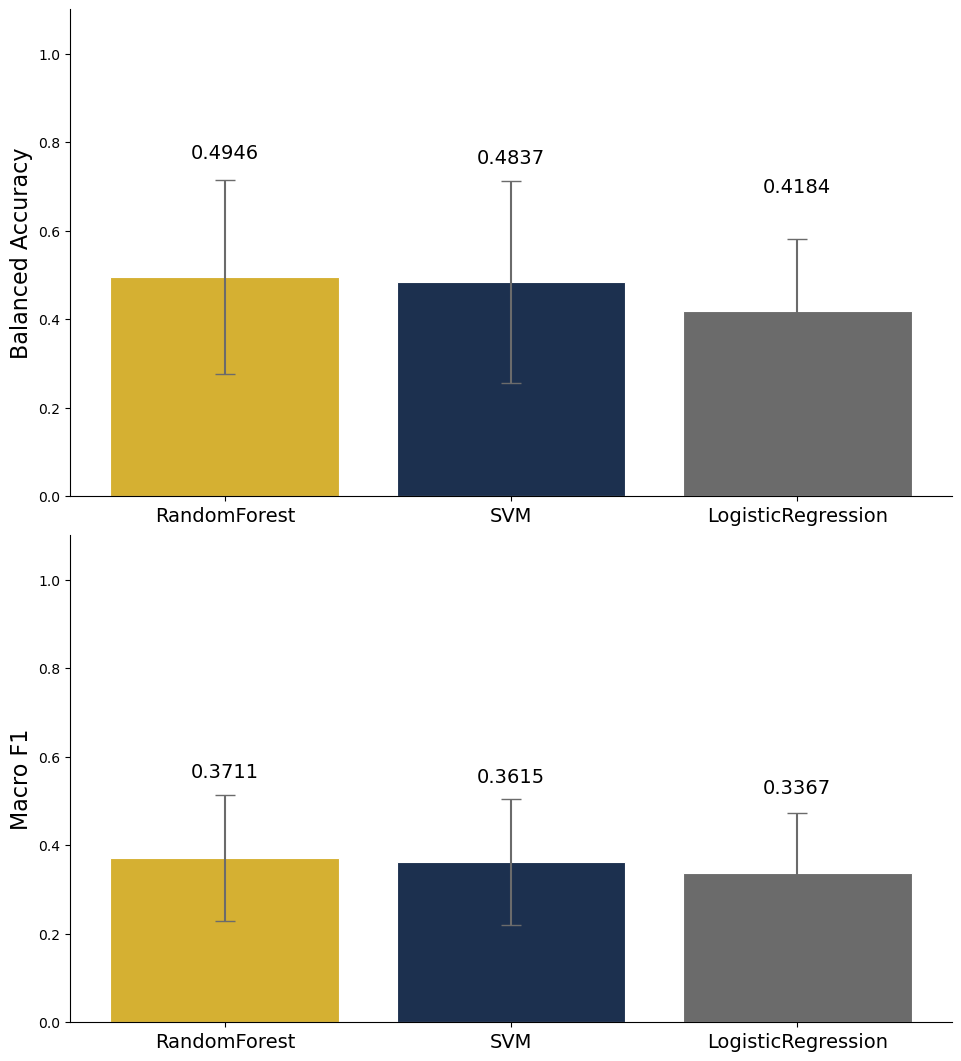

In [ ]:
# ==========================================
# PANEL A — FINAL OUTER-LOOP MODEL PERFORMANCE
# Uses final_outer_summary_df from the reporting cell
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

if "final_outer_summary_df" not in globals():
    raise ValueError("Run the final outer-loop reporting cell first so final_outer_summary_df exists.")

fig, axes = plt.subplots(2, 1, figsize=(9.5, 10.5), constrained_layout=True)
fig.patch.set_alpha(0)

plot_df = final_outer_summary_df.copy()

models   = plot_df["Model"].tolist()
bal_acc  = plot_df["mean_balanced_accuracy"].values
bal_std  = plot_df["std_balanced_accuracy"].values
mac_f1   = plot_df["mean_macro_f1"].values
mac_std  = plot_df["std_macro_f1"].values

# --- CONSISTENT PALETTE ---
SUBORDINATE = (213/255, 176/255, 50/255)  # mustard
DOMINANT    = (28/255, 48/255, 79/255)    # navy
GRAY        = "#6B6B6B"

# First two colored, remaining gray
base_colors = [SUBORDINATE, DOMINANT]
colors = base_colors + [GRAY] * max(0, len(models) - len(base_colors))
colors = colors[:len(models)]

x = np.arange(len(models))

for ax, means, stds, ylabel in [
    (axes[0], bal_acc, bal_std, "Balanced Accuracy"),
    (axes[1], mac_f1,  mac_std, "Macro F1"),
]:
    ax.set_facecolor("none")

    bars = ax.bar(
        x,
        means,
        yerr=stds,
        capsize=7,
        color=colors,
        edgecolor="white",
        linewidth=0.8,
        error_kw=dict(elinewidth=1.5, ecolor=GRAY)
    )

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=16)
    ax.set_ylim(0, 1.1)

    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(False)

    y_offset = max(stds) + 0.03 if len(stds) else 0.03
    for bar, m in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + y_offset,
            f"{m:.4f}",
            ha="center",
            va="bottom",
            fontsize=14
        )

plt.savefig("panel_A_rank_final_outer_loop.svg", bbox_inches="tight", transparent=True)
plt.show()

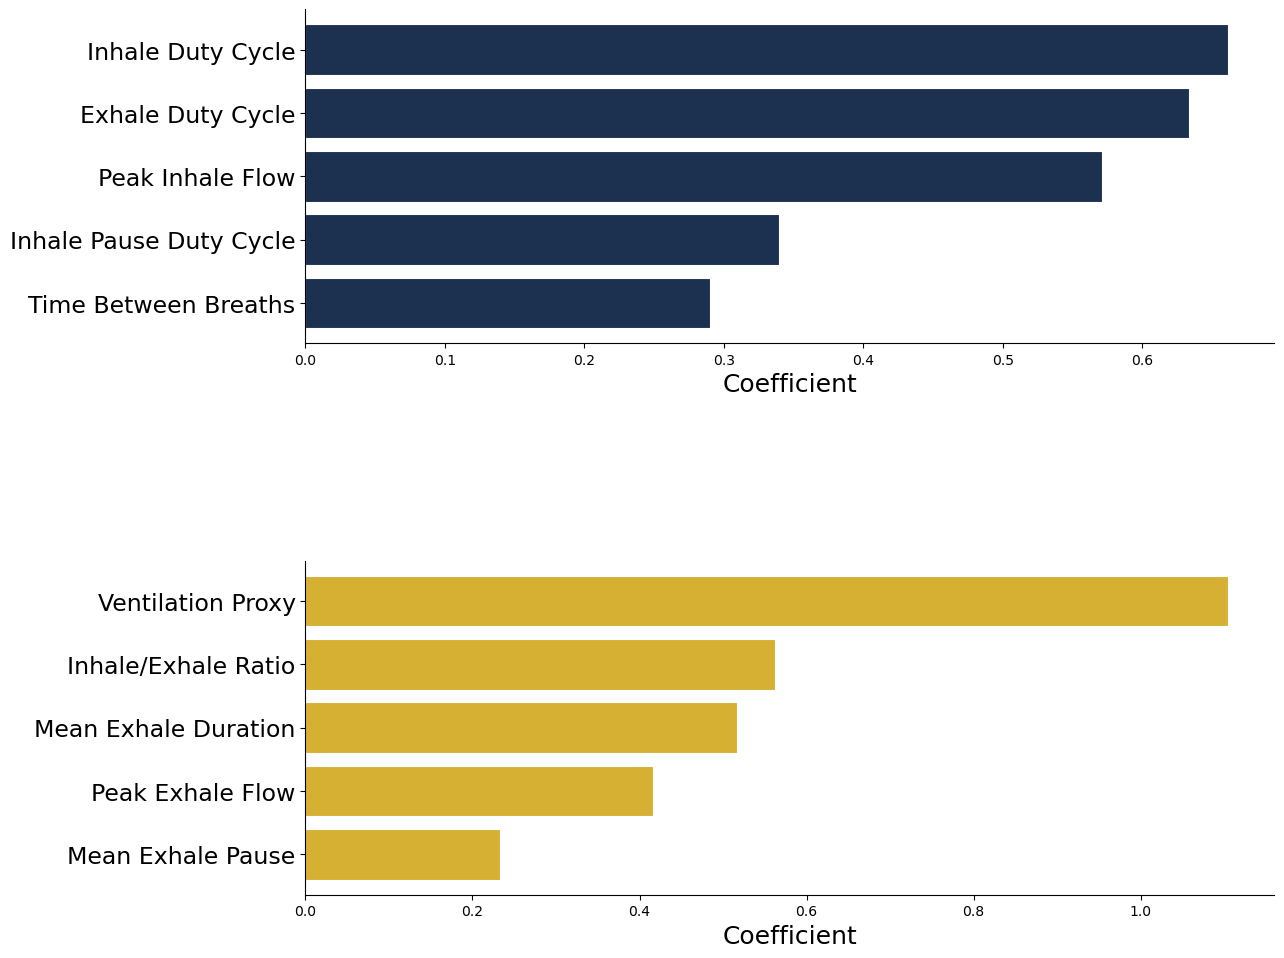

lr.classes_ = ['DOM' 'SUB']
class0 = DOM | color = (0.10980392156862745, 0.18823529411764706, 0.30980392156862746)
class1 = SUB | color = (0.8352941176470589, 0.6901960784313725, 0.19607843137254902)


In [ ]:
# ================================
# CLEAN FEATURE IMPORTANCE PLOT
# ================================

import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# --- consistent palette ---
SUBORDINATE = (213/255, 176/255, 50/255)  # mustard
DOMINANT    = (28/255, 48/255, 79/255)    # navy

# --- most common best C from nested CV ---
def _best_c(default=1.0):
    if "nested_results" not in globals() or "LogisticRegression" not in nested_results:
        return default

    c_vals = [
        r["best_params"]["model__C"]
        for r in nested_results["LogisticRegression"].get("best_params_per_subject", [])
        if "model__C" in r.get("best_params", {})
    ]
    return Counter(c_vals).most_common(1)[0][0] if c_vals else default

best_c = _best_c()

# --- fit coefficient model on full dataset ---
coef_pipe = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        C=best_c,
        random_state=42
    )),
])

coef_pipe.fit(X, y)

lr = coef_pipe.named_steps["model"]
if lr.coef_.shape[0] != 1:
    raise ValueError("This plotting cell expects binary logistic regression.")

coef = pd.Series(lr.coef_[0], index=X.columns)
class0, class1 = lr.classes_

TOP_N = 5
class0_top = coef.sort_values().head(TOP_N)
class1_top = coef.sort_values(ascending=False).head(TOP_N)

feature_name_map = {
    "n_breaths": "Breath Count",
    "breathing_rate_hz": "Breathing Rate",
    "mean_ibi_sec": "Time Between Breaths",
    "cv_breathing_rate": "Breathing Rate Variability",
    "mean_inhale_dur_sec": "Mean Inhale Duration",
    "cv_inhale_dur": "Inhale Duration Variability",
    "mean_exhale_dur_sec": "Mean Exhale Duration",
    "cv_exhale_dur": "Exhale Duration Variability",
    "ie_ratio": "Inhale/Exhale Ratio",
    "mean_peak_insp_flow": "Peak Inhale Flow",
    "mean_peak_exp_flow": "Peak Exhale Flow",
    "cv_peak_insp_flow": "Inhale Flow Variability",
    "mean_inhale_vol": "Mean Inhale Volume",
    "mean_exhale_vol": "Mean Exhale Volume",
    "mean_tidal_vol": "Mean Tidal Volume",
    "cv_tidal_vol": "Tidal Volume Variability",
    "minute_ventilation": "Minute Ventilation",
    "pct_breaths_with_inhale_pause": "Inhale Pauses (%)",
    "mean_inhale_pause_dur_sec": "Mean Inhale Pause",
    "cv_inhale_pause_dur": "Inhale Pause Variability",
    "inhale_pause_duty_cycle": "Inhale Pause Duty Cycle",
    "pct_breaths_with_exhale_pause": "Exhale Pauses (%)",
    "mean_exhale_pause_dur_sec": "Mean Exhale Pause",
    "cv_exhale_pause_dur": "Exhale Pause Variability",
    "exhale_pause_duty_cycle": "Exhale Pause Duty Cycle",
    "inhale_duty_cycle": "Inhale Duty Cycle",
    "exhale_duty_cycle": "Exhale Duty Cycle",
}

def pretty_name(name):
    return feature_name_map.get(name, name.replace("_", " ").title())

def class_color(label):
    s = str(label).strip().lower()
    if s in {"sub", "subordinate"}:
        return SUBORDINATE
    if s in {"dom", "dominant"}:
        return DOMINANT
    return "#777777"

class0_labels = [pretty_name(x) for x in class0_top.index[::-1]]
class1_labels = [pretty_name(x) for x in class1_top.index[::-1]]

fig, axes = plt.subplots(2, 1, figsize=(12.5, 11.5))
fig.patch.set_alpha(0)
fig.subplots_adjust(hspace=0.65)

# --- class0 ---
axes[0].set_facecolor("none")
axes[0].barh(
    range(TOP_N),
    np.abs(class0_top.values[::-1]),
    color=class_color(class0),
    edgecolor="white",
    linewidth=0.8
)
axes[0].set_yticks(range(TOP_N))
axes[0].set_yticklabels(class0_labels, fontsize=17)
axes[0].set_xlabel("Coefficient", fontsize=18)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(False)

# --- class1 ---
axes[1].set_facecolor("none")
axes[1].barh(
    range(TOP_N),
    class1_top.values[::-1],
    color=class_color(class1),
    edgecolor="white",
    linewidth=0.8
)
axes[1].set_yticks(range(TOP_N))
axes[1].set_yticklabels(class1_labels, fontsize=17)
axes[1].set_xlabel("Coefficient", fontsize=18)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(False)

plt.savefig("panel_C_rank_top_features.svg", bbox_inches="tight", transparent=True)
plt.show()

print("lr.classes_ =", lr.classes_)
print("class0 =", class0, "| color =", class_color(class0))
print("class1 =", class1, "| color =", class_color(class1))

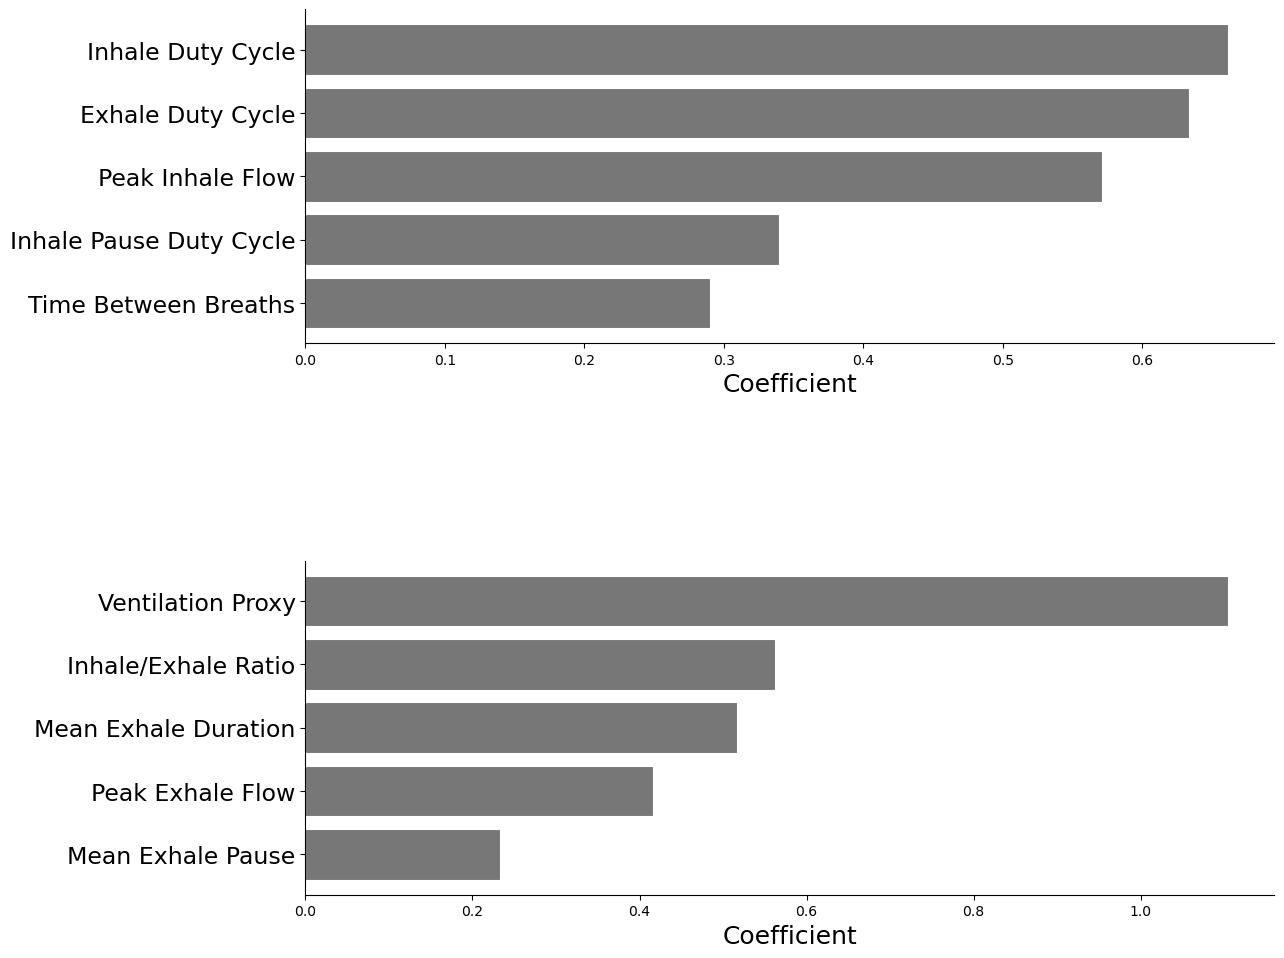

In [ ]:
# ==========================================
# PANEL C — TOP FEATURES (RANK, FINAL STYLE)
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# --- CONSISTENT PALETTE ---
SUBORDINATE = (213/255, 176/255, 50/255)  # mustard
DOMINANT    = (28/255, 48/255, 79/255)    # navy

# --- choose best C from nested search ---
def _best_c(default=1.0):
    if "nested_results" not in globals() or "LogisticRegression" not in nested_results:
        return default
    c_vals = [
        r["best_params"]["model__C"]
        for r in nested_results["LogisticRegression"].get("best_params_per_subject", [])
        if "model__C" in r.get("best_params", {})
    ]
    return Counter(c_vals).most_common(1)[0][0] if c_vals else default

best_c = _best_c()

coef_pipe = Pipeline([
    ("preprocess", preprocess_numeric),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        C=best_c,
        random_state=42
    )),
])

coef_pipe.fit(X, y)

lr = coef_pipe.named_steps["model"]
if lr.coef_.shape[0] != 1:
    raise ValueError("This plotting cell expects binary logistic regression.")

coef = pd.Series(lr.coef_[0], index=X.columns)
class0, class1 = lr.classes_

TOP_N = 5
class0_top = coef.sort_values().head(TOP_N)                  # negative side
class1_top = coef.sort_values(ascending=False).head(TOP_N)   # positive side

# Feature name cleanup
feature_name_map = {
    "n_breaths": "Breath Count",
    "breathing_rate_hz": "Breathing Rate",
    "mean_ibi_sec": "Time Between Breaths",
    "cv_breathing_rate": "Breathing Rate Variability",
    "mean_inhale_dur_sec": "Mean Inhale Duration",
    "cv_inhale_dur": "Inhale Duration Variability",
    "mean_exhale_dur_sec": "Mean Exhale Duration",
    "cv_exhale_dur": "Exhale Duration Variability",
    "ie_ratio": "Inhale/Exhale Ratio",
    "mean_peak_insp_flow": "Peak Inhale Flow",
    "mean_peak_exp_flow": "Peak Exhale Flow",
    "cv_peak_insp_flow": "Inhale Flow Variability",
    "mean_inhale_vol": "Mean Inhale Volume",
    "mean_exhale_vol": "Mean Exhale Volume",
    "mean_tidal_vol": "Mean Tidal Volume",
    "cv_tidal_vol": "Tidal Volume Variability",
    "minute_ventilation": "Minute Ventilation",
    "pct_breaths_with_inhale_pause": "Inhale Pauses (%)",
    "mean_inhale_pause_dur_sec": "Mean Inhale Pause",
    "cv_inhale_pause_dur": "Inhale Pause Variability",
    "inhale_pause_duty_cycle": "Inhale Pause Duty Cycle",
    "pct_breaths_with_exhale_pause": "Exhale Pauses (%)",
    "mean_exhale_pause_dur_sec": "Mean Exhale Pause",
    "cv_exhale_pause_dur": "Exhale Pause Variability",
    "exhale_pause_duty_cycle": "Exhale Pause Duty Cycle",
    "inhale_duty_cycle": "Inhale Duty Cycle",
    "exhale_duty_cycle": "Exhale Duty Cycle",
}

def pretty_name(name):
    return feature_name_map.get(name, name.replace("_", " ").title())

class0_labels = [pretty_name(x) for x in class0_top.index[::-1]]
class1_labels = [pretty_name(x) for x in class1_top.index[::-1]]

# Match actual class names to your desired colors
def class_color(label):
    if str(label).lower() == "subordinate":
        return SUBORDINATE
    if str(label).lower() == "dominant":
        return DOMINANT
    return "#777777"

fig, axes = plt.subplots(2, 1, figsize=(12.5, 11.5))
fig.patch.set_alpha(0)
fig.subplots_adjust(hspace=0.65)

# --- class0 ---
axes[0].set_facecolor("none")
axes[0].barh(
    range(TOP_N),
    np.abs(class0_top.values[::-1]),
    color=class_color(class0),
    edgecolor="white",
    linewidth=0.8
)
axes[0].set_yticks(range(TOP_N))
axes[0].set_yticklabels(class0_labels, fontsize=17)
axes[0].set_xlabel("Coefficient", fontsize=18)
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].grid(False)

# --- class1 ---
axes[1].set_facecolor("none")
axes[1].barh(
    range(TOP_N),
    class1_top.values[::-1],
    color=class_color(class1),
    edgecolor="white",
    linewidth=0.8
)
axes[1].set_yticks(range(TOP_N))
axes[1].set_yticklabels(class1_labels, fontsize=17)
axes[1].set_xlabel("Coefficient", fontsize=18)
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].grid(False)

plt.savefig("panel_C_rank_top_features.svg", bbox_inches="tight", transparent=True)
plt.show()

In [ ]:
# ==========================================
# OPTIONAL — PER-SUBJECT OUTER-LOOP RESULTS
# ==========================================

import pandas as pd
import numpy as np

if "nested_results" not in globals() or not nested_results:
    raise ValueError("Run the nested strict LOSO cell first so nested_results exists.")

rows = []
for model_name, vals in nested_results.items():
    for r in vals.get("best_params_per_subject", []):
        rows.append({
            "Model": model_name,
            "HeldOutSubject": r.get("held_out_subject"),
            "n_test_windows": r.get("n_test_windows", np.nan),
            "Window_BalancedAccuracy": r.get("test_balanced_accuracy_window", np.nan),
            "Window_MacroF1": r.get("test_macro_f1_window", np.nan),
            "Recording_BalancedAccuracy": r.get("test_balanced_accuracy_recording", np.nan),
            "Recording_MacroF1": r.get("test_macro_f1_recording", np.nan),
            "InnerCV_BestScore": r.get("best_inner_cv_score", np.nan),
            "BestParams": r.get("best_params", {}),
        })

per_subject_outer_df = pd.DataFrame(rows)
display(per_subject_outer_df.sort_values(["Model", "Window_BalancedAccuracy"], ascending=[True, False]))

,Model,HeldOutSubject,n_test_windows,Window_BalancedAccuracy,Window_MacroF1,Recording_BalancedAccuracy,Recording_MacroF1,InnerCV_BestScore,BestParams
3,LogisticRegression,2_1,100,0.750000,0.428571,1.0,0.500000,0.416107,{'model__C': 100.0}
7,LogisticRegression,3_3,197,0.563041,0.562900,1.0,1.000000,0.430888,{'model__C': 100.0}
10,LogisticRegression,4_3,100,0.530000,0.346405,1.0,0.500000,0.460891,{'model__C': 100.0}
11,LogisticRegression,5_1,189,0.528070,0.527779,0.5,0.333333,0.458329,{'model__C': 100.0}
9,LogisticRegression,4_2,99,0.525253,0.344371,1.0,0.500000,0.491663,{'model__C': 100.0}
...,...,...,...,...,...,...,...,...,...
28,SVM,5_1,189,0.341215,0.335714,0.0,0.000000,0.568072,"{'model__C': 100.0, 'model__gamma': 0.01}"
33,SVM,8_2,100,0.260000,0.206349,0.0,0.000000,0.581087,"{'model__C': 0.1, 'model__gamma': 1.0}"
27,SVM,4_3,100,0.160000,0.137931,0.0,0.000000,0.588166,"{'model__C': 0.1, 'model__gamma': 1.0}"
26,SVM,4_2,99,0.151515,0.131579,0.0,0.000000,0.564888,"{'model__C': 1.0, 'model__gamma': 0.1}"
